# Identificación de Insumos Críticos por Familia de Compra
## K-Means — Volumen relativo × Alcance productivo × Lead Time

**Proyecto Final de Ingeniería Industrial — FCEIA / UNR**
**Empresa:** Maincal S.A.
**Autores:** Guaita, Jerónimo · Ovando, Ignacio

---

### Objetivo
Clasificar las familias de insumos en niveles de criticidad (**CRÍTICO / IMPORTANTE / SECUNDARIO**)
utilizando un modelo de *Machine Learning* no supervisado (K-Means), a partir de tres dimensiones:

| Feature | Descripción |
|---|---|
| **Volumen relativo** | Consumo proyectado normalizado dentro de su Unidad de Medida (0–100) |
| **Alcance productivo** | Porcentaje de artículos padre que dependen de ese insumo |
| **Lead Time** | Plazo de reposición normalizado (0–100): riesgo temporal ante un quiebre |

### Flujo del notebook

```
0. Librerías
1. Parámetros configurables
2. Carga de datos (Forecast Prophet + BOM)
3. Curva de talles y explosión BOM (consumos proyectados)
4. Agrupamiento en familias de compra
5. Feature engineering
6. K-Means — selección de K y entrenamiento
7. Resultados y visualización
8. Detalle: SKUs hijo por familia
9. Políticas de inventario para insumos críticos
10. Exportación a Excel
11. Conclusiones
```

> **Dónde vive el código:** el cálculo está en el paquete `planificacion/insumos/`
> (`curva_talles`, `bom`, `familias`, `features`, `clustering`, `politicas`, `graficos`,
> `reporte_excel`) y los parámetros en `planificacion/config.py`. Este notebook solo orquesta
> y documenta. Las funciones puras tienen tests en `tests/` (`python -m pytest tests/`).


---
## 0. Librerías


In [1]:
import pandas as pd

from planificacion import estilos, io_datos
from planificacion.config import InsumosConfig
from planificacion.insumos import (bom, clustering, curva_talles, familias,
                                   features, graficos, politicas, reporte_excel)

print("✅ Librerías cargadas")


✅ Librerías cargadas


---
## 1. Parámetros configurables

Todos los parámetros del modelo están concentrados acá.  
Modificar esta celda es suficiente para re-ejecutar el análisis con distintos criterios.


In [2]:
cfg = InsumosConfig()

print("✅ Parámetros configurados")
print(cfg.resumen())


✅ Parámetros configurados
K = 3  |  Talles: 34–50  |  Archivo salida: Insumos_Criticos.xlsx
Pesos score → Vol=0.084  Alcance=0.604  LeadTime=0.312


---
## 2. Carga de datos

Se cargan dos fuentes:
- **Forecast de ventas** (salida del modelo Prophet): columnas `Articulo`, `Fecha`, `Ventas`, `Tipo`
- **BOM (Bill of Materials)**: relación artículo → componente → cantidad por talle


In [3]:
df_forecast = io_datos.cargar_forecast(cfg.forecast_path)
df_bom = io_datos.cargar_bom(cfg.bom_path)

print(f"Forecast: {df_forecast.shape[0]} filas | Tipos: {list(df_forecast['Tipo'].unique())}")
print(f"BOM     : {df_bom.shape[0]} filas | Artículos: {df_bom['Articulo'].nunique()}")
df_forecast.head(3)


Forecast: 252 filas | Tipos: ['Historico', 'Pronostico']
BOM     : 1172 filas | Artículos: 6


,Articulo,Fecha,Ventas,Tipo
0,CRONOS-N04,2023-01-01,5895.000000,Historico
1,CRONOS-N04,2023-01-01,5419.924865,Pronostico
2,CRONOS-N04,2023-02-01,6405.000000,Historico


In [4]:
df_bom.head(3)


,Material,Articulo,Talle,Componente,Componente de lista de materia,Cantidad,UM,Proveedor,Precio,Moneda,Lead Time
0,1000050069,ARGOS 2-N04,34,4000318006,"SISTEMA PU TINTA, NEGRO",2.8,G,30000007 POLIRESINAS SAN LUIS S.A.,8.0,USD,30
1,1000050070,ARGOS 2-N04,35,4000318006,"SISTEMA PU TINTA, NEGRO",2.8,G,30000007 POLIRESINAS SAN LUIS S.A.,8.0,USD,30
2,1000050071,ARGOS 2-N04,36,4000318006,"SISTEMA PU TINTA, NEGRO",2.8,G,30000007 POLIRESINAS SAN LUIS S.A.,8.0,USD,30


---
## 3. Curva de talles y explosión BOM

El forecast viene a nivel artículo (sin discriminar talle).  
Se desagrega multiplicando por la curva de talles (distribución normal),
y luego se cruza con el BOM para calcular el **consumo proyectado** de cada componente.

$$\text{Consumo}_{\text{componente}} = \sum_{\text{talles}} \left( \text{Forecast}_{\text{artículo}} \times p_{\text{talle}} \times \text{Cantidad}_{\text{BOM}} \right)$$


Talles: 34–50  |  Suma proporciones: 1.000000


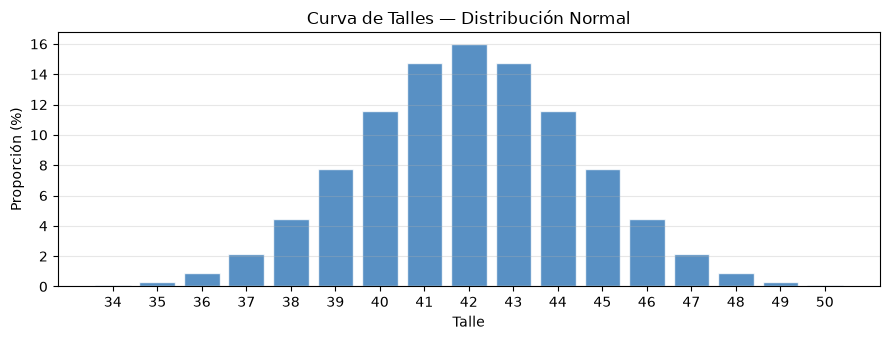

In [5]:
df_curva = curva_talles.construir_curva_de_talles(cfg)
graficos.curva_talles(df_curva);

print(f"Talles: {df_curva['talle'].min()}–{df_curva['talle'].max()}  |  "
      f"Suma proporciones: {df_curva['proporcion'].sum():.6f}")


In [6]:
tipo_pronostico = bom.detectar_tipo_pronostico(df_forecast, cfg.tipo_pronostico)
print(f"Valores únicos en 'Tipo': {list(df_forecast['Tipo'].unique())}")
print(f"→ Se usa como pronóstico: '{tipo_pronostico}'")

df_cp, diagnostico = bom.explotar_a_consumo_de_insumos(df_forecast, df_bom, df_curva, tipo_pronostico)
print(diagnostico)

print(f"\n✅ Filas en consumo proyectado: {len(df_cp):,}")
df_cp[['Articulo_Padre', 'talle', 'forecast_talle',
       'Nombre_Componente_Insumo', 'Cantidad', 'consumo_proyectado']].head(5)


Valores únicos en 'Tipo': ['Historico', 'Pronostico']
→ Se usa como pronóstico: 'Pronostico'
⚠️  Artículos en BOM SIN forecast asociado (se ignoran): ['ARGOS 2-N04', 'JANO 2-N04', 'SOUL-G09']

✅ Filas en consumo proyectado: 27,696


,Articulo_Padre,talle,forecast_talle,Nombre_Componente_Insumo,Cantidad,consumo_proyectado
0,CRONOS-N04,34,5.17,"SISTEMA PU TINTA, NEGRO",2.8,14.476
1,CRONOS-N04,34,5.17,"SISTEMA PU TINTA, GRIS",12.2,63.074
2,CRONOS-N04,34,5.17,PUNTERA ACERO 59 NORMAL T7,1.0,5.170
3,CRONOS-N04,34,5.17,PLANT VIS PLANA 4mm VORAN NEGRO T34,1.0,5.170
4,CRONOS-N04,34,5.17,"PLANT ARM STROB VORAN H450/3 T34,5",1.0,5.170


---
## 4. Agrupamiento en familias de compra

Los insumos que varían únicamente por talle se consolidan en una **familia de compra**,
que es la unidad real de decisión del área de Compras.

**Lógica:**
- Se elimina el sufijo de talle del nombre del componente (`nombre_base`).
- Luego se aplican reglas explícitas para agrupar familias con nomenclaturas distintas
  pero que corresponden al mismo artículo de compra (ej: `PUNTERA ACERO 59 NORMAL T9` y
  `PUNTERA ACERO 59 NORMAL T10` → `PUNTERA ACERO 59 NORMAL`).


In [7]:
df_cp = familias.asignar_familias_de_compra(df_cp)
TOTAL_ART = df_cp['Articulo_Padre'].nunique()

print(f"Artículos padre únicos: {TOTAL_ART}")
print(f"Insumos base únicos   : {df_cp['Nombre_Base'].nunique()}")
print(f"Familias de compra    : {df_cp['Familia'].nunique()}  ← unidad de análisis")


Artículos padre únicos: 3
Insumos base únicos   : 90
Familias de compra    : 24  ← unidad de análisis


---
## 5. Feature engineering

Para cada familia de compra se calculan las **tres** variables de entrada al modelo:

| Variable | Fórmula | Interpretación |
|---|---|---|
| `Vol_norm` | $\frac{\text{Consumo}_i}{\max(\text{Consumo}_{UM})} \times 100$ | Cuánto representa este insumo dentro de su UM (0–100) |
| `Alcance_pct` | $\frac{N_{\text{artículos que lo usan}}}{N_{\text{total artículos}}} \times 100$ | Qué porcentaje de los artículos padre dependen de este insumo |
| `LeadTime_norm` | $\frac{LT_i - LT_{min}}{LT_{max} - LT_{min}} \times 100$ | Riesgo de abastecimiento: a mayor Lead Time, menor margen de reacción ante un quiebre de stock |

> La normalización por UM (Vol_norm) y la normalización min-max (LeadTime_norm) permiten comparar
> magnitudes heterogéneas (gramos, pares, unidades, días) en una misma escala 0–100, condición
> necesaria para que ninguna variable domine arbitrariamente la distancia euclidiana del K-Means.

El **Lead Time** (columna agregada manualmente en `BOM_Zapato_Terminado.xlsx`, junto con
`Proveedor` y `Precio`) se incorpora como tercera variable de clasificación porque captura una
dimensión que el Volumen y el Alcance no reflejan: el **riesgo temporal de reposición**. Un insumo
puede tener bajo volumen y alcance acotado, pero si su Lead Time es muy extendido (ej. importado,
proveedor único), su quiebre de stock puede ser igualmente disruptivo.


In [8]:
df_fam = features.calcular_variables_de_criticidad(features.consolidar_por_familia_de_compra(df_cp, cfg), TOTAL_ART)

print(f"Familias de compra con consumo > 0: {len(df_fam)}")
print(f"Lead Time ({cfg.leadtime_unidad}) → min: {df_fam['Lead_Time_dias'].min():.0f}  "
      f"max: {df_fam['Lead_Time_dias'].max():.0f}")
df_fam[['Familia', 'UM', 'Consumo_Total', 'N_SKUs_hijo', 'N_Articulos',
        'Lead_Time_dias', 'Proveedor', 'Alcance_pct', 'Vol_norm', 'LeadTime_norm']] \
    .sort_values('Consumo_Total', ascending=False)


Familias de compra con consumo > 0: 24
Lead Time (días) → min: 5  max: 45


,Familia,UM,Consumo_Total,N_SKUs_hijo,N_Articulos,Lead_Time_dias,Proveedor,Alcance_pct,Vol_norm,LeadTime_norm
4,CONJ SISTEMA PU,G,3.984863e+08,1,3,45,30000007 POLIRESINAS SAN LUIS S.A.,100.000000,100.000000,100.0
21,"SISTEMA PU TINTA, GRIS",G,1.011370e+07,1,3,30,30000007 POLIRESINAS SAN LUIS S.A.,100.000000,2.538028,62.5
23,"SISTEMA PU TINTA, NEGRO",G,1.866361e+06,1,2,30,30000007 POLIRESINAS SAN LUIS S.A.,66.666667,0.468363,62.5
22,"SISTEMA PU TINTA, HUESO",G,7.077483e+05,1,1,30,30000007 POLIRESINAS SAN LUIS S.A.,33.333333,0.177609,62.5
9,"CORDON TRENZ NEGRO, 0,90m",PAA,6.665574e+05,1,2,5,30000008 AVIOS SA,66.666667,100.000000,0.0
18,PUNTERA ACERO 59 NORMAL,PAA,6.665574e+05,6,2,40,40000002 FLECKSTEEL IND. ART. METALICOS LTDA,66.666667,100.000000,87.5
14,PLANTILLA ARM STROB VORAN,PAA,6.665574e+05,12,2,7,NaN,66.666667,100.000000,5.0
0,CAJA EMPAQUE (BOTA/BOTÍN),UN,6.665574e+05,2,2,30,30001763 PAPEL PACK ENVASES SRL,66.666667,100.000000,62.5
17,PLANTILLA VIS PLANA VORAN NEGRO,PAA,6.660719e+05,17,2,7,NaN,66.666667,99.927168,5.0
1,"CAPELLADA CRONOS, -N, (NA)",PAA,5.087509e+05,1,1,25,NaN,33.333333,76.325145,50.0


---
## 6. Modelo K-Means

### ¿Por qué K-Means?

K-Means es un algoritmo de **aprendizaje no supervisado** que agrupa observaciones
minimizando la distancia intra-cluster (inercia). Se eligió porque:

- No requiere datos etiquetados (no existe un histórico de "criticidad")
- Es interpretable: cada cluster tiene un centroide con coordenadas en las mismas
  unidades que los features
- Es computacionalmente eficiente para este volumen de datos

### Selección del K óptimo — Silhouette Score

El **Silhouette Score** mide qué tan bien separado está cada punto de su propio cluster
respecto al cluster vecino más cercano. Rango: −1 (mal) a +1 (perfecto). Se elige el K
que maximiza este indicador.


K con mayor Silhouette : 6  (0.649)
K configurado          : 3
⚠️  El silhouette prefiere K=6: dejar constancia en el informe de por qué se mantiene K=3.


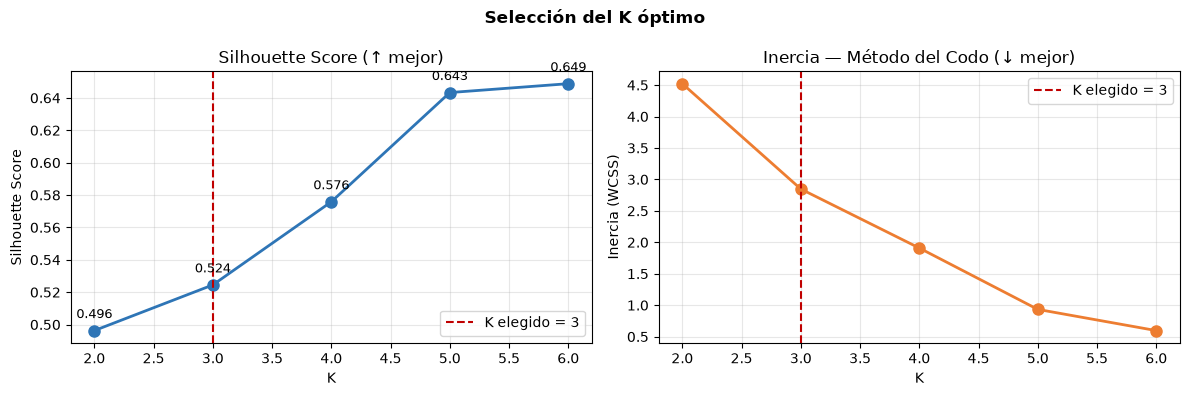

In [9]:
X_sc, scaler = clustering.escalar_variables(df_fam)
df_k = clustering.evaluar_cantidad_de_clusters(X_sc, cfg)
graficos.seleccion_k(df_k, cfg);

mejor_k = int(df_k.loc[df_k['Silhouette'].idxmax(), 'K'])
print(f"K con mayor Silhouette : {mejor_k}  ({df_k['Silhouette'].max():.3f})")
print(f"K configurado          : {cfg.k_clusters}")
if mejor_k != cfg.k_clusters:
    print(f"⚠️  El silhouette prefiere K={mejor_k}: dejar constancia en el informe de por qué "
          f"se mantiene K={cfg.k_clusters}.")
else:
    print("✅ El silhouette confirma el K configurado.")


In [10]:
resultado = clustering.clasificar_por_kmeans(df_fam, X_sc, scaler, cfg)
df_fam = resultado.familias

print(f"Silhouette Score (K={cfg.k_clusters}, {len(features.FEATURES)} features): "
      f"{resultado.silhouette:.3f}")
print("\nCentroides por cluster (escala original):")
print(resultado.resumen_centroides())

print("\nDistribución (todas las familias, incluye producción interna):")
print(df_fam['Criticidad'].value_counts().to_string())

n_internas = int((~df_fam['Es_Compra_Externa']).sum())
print(f"\n⚠️  {n_internas} familia(s) de producción interna participaron del clustering pero se")
print("    excluyen del alcance de Compras en tabla, gráfico y Excel finales:")
print(df_fam.loc[~df_fam['Es_Compra_Externa'], ['Familia', 'Criticidad']].to_string(index=False))


Silhouette Score (K=3, 3 features): 0.524

Centroides por cluster (escala original):
  [CRÍTICO]  Vol_norm=  96.6  Alcance_pct= 66.7  LeadTime_norm=  44.3
  [IMPORTANTE]  Vol_norm=  12.4  Alcance_pct= 44.4  LeadTime_norm=  62.5
  [SECUNDARIO]  Vol_norm=  13.6  Alcance_pct= 33.3  LeadTime_norm=   1.9

Distribución (todas las familias, incluye producción interna):
Criticidad
IMPORTANTE    9
SECUNDARIO    8
CRÍTICO       7

⚠️  7 familia(s) de producción interna participaron del clustering pero se
    excluyen del alcance de Compras en tabla, gráfico y Excel finales:
                        Familia Criticidad
     CAPELLADA CRONOS, -N, (NA)    CRÍTICO
    CAPELLADA HORIZON, -M, (NA) IMPORTANTE
    CAPELLADA TAURO 2, -N, (NA) IMPORTANTE
         PLANTILLA ARM STROB UL SECUNDARIO
      PLANTILLA ARM STROB VORAN    CRÍTICO
    PLANTILLA VIS PLANA FUNC MA SECUNDARIO
PLANTILLA VIS PLANA VORAN NEGRO    CRÍTICO


---
## 7. Resultados y visualización

> **Alcance**: la tabla, el gráfico y el Excel de esta sección muestran únicamente las
> familias con `Proveedor` asignado (decisión real de Compras). Las familias de producción
> interna (capelladas, plantillas semielaboradas) participaron del entrenamiento del K-Means
> —para no distorsionar la normalización— pero se excluyen de los resultados aquí, conforme
> al alcance definido en el Anteproyecto.


In [11]:
df_resultado = clustering.tabla_de_familias_clasificadas(resultado, cfg)

cols_display = ['Familia', 'UM', 'Consumo_Total', 'N_SKUs_hijo', 'N_Articulos',
                'Alcance_pct', 'Vol_norm', 'Lead_Time_dias', 'Proveedor', 'Criticidad']
umbral_lt = df_resultado['Lead_Time_dias'].quantile(0.75)   # resalta los LT largos

print(f"Familias dentro del alcance de Compras: {len(df_resultado)} de {len(df_fam)} totales")

(df_resultado[cols_display]
 .style
 .map(estilos.estilo_celda_criticidad, subset=['Criticidad'])
 .map(lambda v: 'background-color: #FCE4E4; font-weight: bold' if v >= umbral_lt else '',
      subset=['Lead_Time_dias'])
 .format({'Consumo_Total': '{:,.0f}', 'Alcance_pct': '{:.1f}', 'Vol_norm': '{:.1f}',
          'Lead_Time_dias': '{:.0f}'})
 .set_caption(f'Familias de compra clasificadas por K-Means (K={cfg.k_clusters}) — '
              f'incluye Lead Time ({cfg.leadtime_unidad}) — solo alcance de Compras')
)


Familias dentro del alcance de Compras: 17 de 24 totales


,Familia,UM,Consumo_Total,N_SKUs_hijo,N_Articulos,Alcance_pct,Vol_norm,Lead_Time_dias,Proveedor,Criticidad
1,CAJA EMPAQUE (BOTA/BOTÍN),UN,"666,557",2,2,66.7,100.0,30,30001763 PAPEL PACK ENVASES SRL,CRÍTICO
2,CONJ SISTEMA PU,G,"398,486,287",1,3,100.0,100.0,45,30000007 POLIRESINAS SAN LUIS S.A.,CRÍTICO
3,"CORDON TRENZ NEGRO, 0,90m",PAA,"666,557",1,2,66.7,100.0,5,30000008 AVIOS SA,CRÍTICO
4,PUNTERA ACERO 59 NORMAL,PAA,"666,557",6,2,66.7,100.0,40,40000002 FLECKSTEEL IND. ART. METALICOS LTDA,CRÍTICO
5,INSERTO B/PU UL DELANTERO,PAA,"141,550",4,1,33.3,21.2,30,30000041 MOLDEPLAST SRL,IMPORTANTE
6,INSERTO B/PU UL TRASERO,PAA,"141,550",4,1,33.3,21.2,30,30000041 MOLDEPLAST SRL,IMPORTANTE
7,PUNTERA ALUMINIO 459 NORMAL,PAA,"141,550",6,1,33.3,21.2,40,40000002 FLECKSTEEL IND. ART. METALICOS LTDA,IMPORTANTE
8,"SISTEMA PU TINTA, GRIS",G,"10,113,695",1,3,100.0,2.5,30,30000007 POLIRESINAS SAN LUIS S.A.,IMPORTANTE
9,"SISTEMA PU TINTA, NEGRO",G,"1,866,361",1,2,66.7,0.5,30,30000007 POLIRESINAS SAN LUIS S.A.,IMPORTANTE
10,"SISTEMA PU TINTA, HUESO",G,"707,748",1,1,33.3,0.2,30,30000007 POLIRESINAS SAN LUIS S.A.,IMPORTANTE


✅ Gráfico guardado: grafico_insumos_criticos.png
   (los números de cada punto corresponden al índice de la Tabla de clasificación)


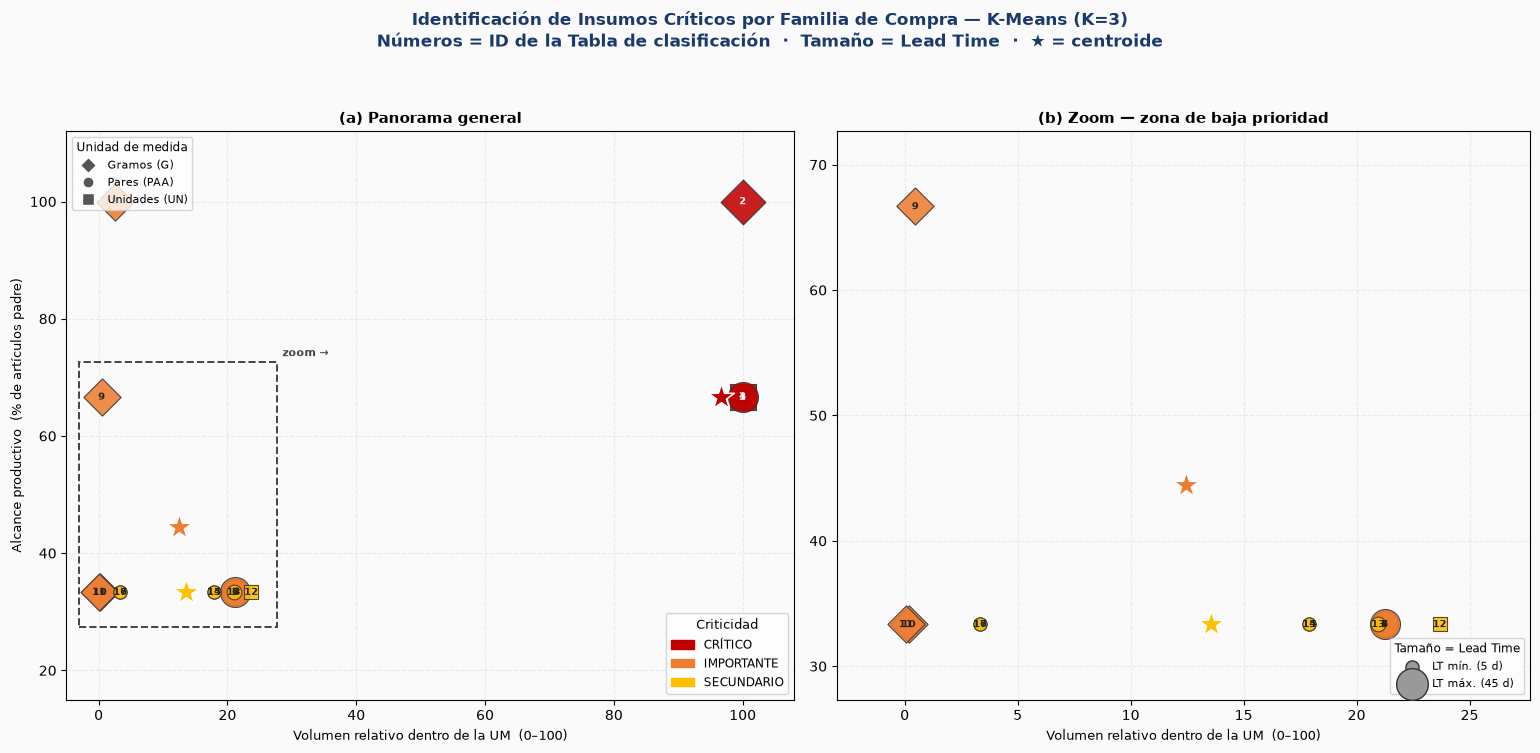

In [12]:
graficos.dispersion(df_resultado, resultado, cfg, cfg.grafico_dispersion);

print(f"✅ Gráfico guardado: {cfg.grafico_dispersion.name}")
print("   (los números de cada punto corresponden al índice de la Tabla de clasificación)")


**Gráfico complementario — Coordenadas Paralelas**

El gráfico anterior proyecta 3 variables en un plano 2D, lo que inevitablemente compacta
información. Las **Coordenadas Paralelas** muestran el perfil completo de cada familia en
sus 3 variables simultáneamente, y permiten ver con claridad cómo cada nivel de
Criticidad corresponde a un patrón distinto (no solo a un punto en el espacio).

✅ Gráfico guardado: grafico_coordenadas_paralelas.png


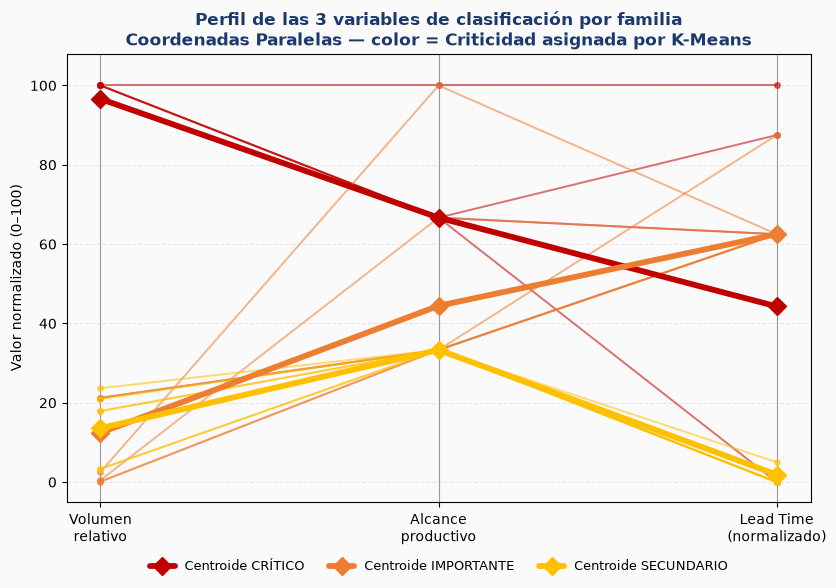

In [13]:
graficos.coordenadas_paralelas(df_resultado, resultado, cfg, cfg.grafico_paralelas);

print(f"✅ Gráfico guardado: {cfg.grafico_paralelas.name}")


**Gráfico complementario — Matriz de decisión multicriterio (heatmap)**

Esquemático y con el detalle numérico de cada variable a la vista: cada fila es una
familia, cada columna una variable normalizada (0–100) más el **Score AHP** que
determina el orden. La franja de color a la izquierda indica la Criticidad asignada
por el K-Means, y las líneas horizontales separan los 3 grupos — permite ver de un
vistazo *por qué* cada familia quedó donde quedó, variable por variable.

✅ Gráfico guardado: grafico_matriz_decision.png


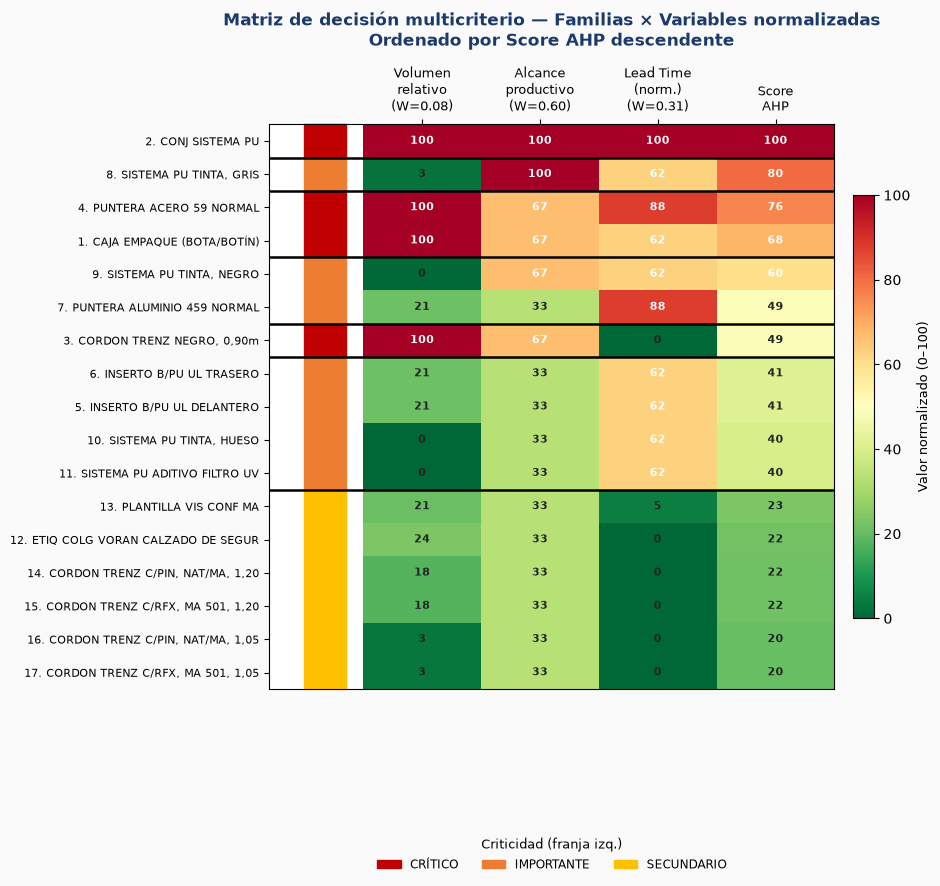

In [14]:
graficos.matriz_decision(df_resultado, cfg, cfg.grafico_heatmap);

print(f"✅ Gráfico guardado: {cfg.grafico_heatmap.name}")


In [15]:
print("=" * 62)
print("  RESUMEN EJECUTIVO")
print("=" * 62)
for etiqueta in cfg.etiquetas:
    sub = df_resultado[df_resultado['Criticidad'] == etiqueta]
    print(f"\n  [{etiqueta}] — {len(sub)} familia(s)")
    for _, r in sub.iterrows():
        print(f"    • {r['Familia']:<44} | {r['UM']:>3} "
              f"| Alcance {r['Alcance_pct']:>5.0f}% | Vol {r['Vol_norm']:>5.1f}")


  RESUMEN EJECUTIVO

  [CRÍTICO] — 4 familia(s)
    • CAJA EMPAQUE (BOTA/BOTÍN)                    |  UN | Alcance    67% | Vol 100.0
    • CONJ SISTEMA PU                              |   G | Alcance   100% | Vol 100.0
    • CORDON TRENZ NEGRO, 0,90m                    | PAA | Alcance    67% | Vol 100.0
    • PUNTERA ACERO 59 NORMAL                      | PAA | Alcance    67% | Vol 100.0

  [IMPORTANTE] — 7 familia(s)
    • INSERTO B/PU UL DELANTERO                    | PAA | Alcance    33% | Vol  21.2
    • INSERTO B/PU UL TRASERO                      | PAA | Alcance    33% | Vol  21.2
    • PUNTERA ALUMINIO 459 NORMAL                  | PAA | Alcance    33% | Vol  21.2
    • SISTEMA PU TINTA, GRIS                       |   G | Alcance   100% | Vol   2.5
    • SISTEMA PU TINTA, NEGRO                      |   G | Alcance    67% | Vol   0.5
    • SISTEMA PU TINTA, HUESO                      |   G | Alcance    33% | Vol   0.2
    • SISTEMA PU ADITIVO FILTRO UV                 |   G | Al

---
## 8. Detalle: SKUs hijo por familia

Muestra exactamente qué variantes (talles) componen cada familia,
útil para el área de Compras al momento de emitir órdenes de compra.


In [16]:
df_sku = clustering.tabla_de_skus_por_familia(df_cp, df_resultado, df_fam, TOTAL_ART, cfg)

print(f"SKUs hijo dentro del alcance de Compras: {len(df_sku)}")

(df_sku[['Criticidad', 'Familia', 'UM', 'Nombre_Base', 'Consumo_SKU', 'N_Art', 'Alcance_pct']]
 .style
 .apply(lambda fila: estilos.estilo_fila_criticidad(fila['Criticidad'], len(fila)), axis=1)
 .format({'Consumo_SKU': '{:,.0f}', 'Alcance_pct': '{:.1f}'})
 .set_caption('SKUs hijo detallados por familia de compra — solo alcance de Compras')
)


SKUs hijo dentro del alcance de Compras: 41


,Criticidad,Familia,UM,Nombre_Base,Consumo_SKU,N_Art,Alcance_pct
1,CRÍTICO,CAJA EMPAQUE (BOTA/BOTÍN),UN,CAJA EMPAQUE BOTIN VORAN ESTUCHE,"613,838",2,66.7
2,CRÍTICO,CAJA EMPAQUE (BOTA/BOTÍN),UN,CAJA EMPAQUE BOTA VORAN,"52,719",2,66.7
3,CRÍTICO,CONJ SISTEMA PU,G,CONJ SISTEMA PU,"398,486,287",3,100.0
4,CRÍTICO,"CORDON TRENZ NEGRO, 0,90m",PAA,"CORDON TRENZ NEGRO, 0,90m","666,557",2,66.7
5,CRÍTICO,PUNTERA ACERO 59 NORMAL,PAA,PUNTERA ACERO 59 NORMAL T10,"204,683",2,66.7
6,CRÍTICO,PUNTERA ACERO 59 NORMAL,PAA,PUNTERA ACERO 59 NORMAL T11,"175,537",2,66.7
7,CRÍTICO,PUNTERA ACERO 59 NORMAL,PAA,PUNTERA ACERO 59 NORMAL T9,"129,093",2,66.7
8,CRÍTICO,PUNTERA ACERO 59 NORMAL,PAA,PUNTERA ACERO 59 NORMAL T12,"104,526",2,66.7
9,CRÍTICO,PUNTERA ACERO 59 NORMAL,PAA,PUNTERA ACERO 59 NORMAL T8,"29,592",2,66.7
10,CRÍTICO,PUNTERA ACERO 59 NORMAL,PAA,PUNTERA ACERO 59 NORMAL T7,"23,126",2,66.7


---
## 9. Políticas de inventario para los insumos críticos seleccionados

Para Conjunto Sistema PU, Puntera Acero 59 Normal y Caja de Empaque se define una política
de inventario diferenciada según su forma real de aprovisionamiento (ya documentada en
secciones anteriores):

- **Conjunto Sistema PU** → Revisión continua (s, Q): se repone cuando el stock cae al
  Punto de Pedido (ROP). Insumo de consumo continuo, proveedor único.
- **Puntera Acero y Caja de Empaque** → Revisión periódica (R, S), con R = 30 días
  (ciclo mensual de planificación): se pide hasta un Nivel Objetivo (S) en cada revisión,
  acorde a su naturaleza *make-to-order* / personalizada.

**Estimación de la demanda y su variabilidad a partir del modelo de ML (Prophet):**
- $\bar{d}$ (demanda media mensual del insumo) se obtiene proyectando el pronóstico Prophet
  de cada artículo (solo meses futuros, sin dato histórico real) a través de la curva de
  talles y la BOM — el mismo mecanismo de explosión usado en la Sección 3.
- $\sigma_d$ (variabilidad de la demanda) se estima a partir del **error in-sample** del
  modelo Prophet: la diferencia entre la venta histórica real y el valor que el propio
  modelo predijo para esos mismos períodos históricos, propagada a través de la BOM.

> ⚠️ **Limitación a declarar en el informe**: al ser un error *in-sample* (el modelo ya
> "vio" esos datos al entrenarse), tiende a subestimar la incertidumbre real de un
> pronóstico genuinamente fuera de muestra. El Stock de Seguridad aquí calculado debe
> interpretarse como una **cota conservadora/mínima**, no como el valor definitivo —
> idealmente se validaría con un backtesting out-of-sample en una iteración futura.

In [17]:
df_politicas = politicas.calcular_politicas_de_inventario(df_forecast, df_bom, df_curva, tipo_pronostico, cfg,
                                  familias=df_fam)

print(f"Nivel de servicio aplicado: {cfg.z_servicio} (≈98%)")
df_politicas


Nivel de servicio aplicado: 2.05 (≈98%)


,Familia,UM,Política,Lead_Time_dias,Demanda_media_mensual,Desvio_mensual,Stock_Seguridad,ROP_o_Nivel_Objetivo,Stock_Maximo,Cobertura_SS_dias
0,CONJ SISTEMA PU,G,"Revisión continua (s,Q)",45,8405980.2,328335.1,824359.7,13433330.0,21839310.2,2.9
1,PUNTERA ACERO 59 NORMAL,PAA,"Revisión periódica (R,S)",40,13779.2,470.5,1473.2,33624.8,47404.0,3.2
2,CAJA EMPAQUE (BOTA/BOTÍN),UN,"Revisión periódica (R,S)",30,13779.2,470.5,1363.9,28922.4,42701.6,3.0


In [18]:
df_politicas.to_excel(cfg.politicas_output_path, index=False)
print(f"✅ Excel exportado: {cfg.politicas_output_path.name}")

# Tabla formateada para el informe
(df_politicas
 .style
 .format({'Demanda_media_mensual': '{:,.0f}', 'Desvio_mensual': '{:,.0f}',
          'Stock_Seguridad': '{:,.0f}', 'ROP_o_Nivel_Objetivo': '{:,.0f}',
          'Stock_Maximo': '{:,.0f}', 'Cobertura_SS_dias': '{:.1f}'})
 .set_caption(f'Políticas de inventario propuestas — insumos críticos seleccionados '
              f'(z = {cfg.z_servicio} · 98% de servicio)')
)


✅ Excel exportado: Politicas_Inventario_Insumos_Criticos.xlsx


,Familia,UM,Política,Lead_Time_dias,Demanda_media_mensual,Desvio_mensual,Stock_Seguridad,ROP_o_Nivel_Objetivo,Stock_Maximo,Cobertura_SS_dias
0,CONJ SISTEMA PU,G,"Revisión continua (s,Q)",45,"8,405,980","328,335","824,360","13,433,330","21,839,310",2.9
1,PUNTERA ACERO 59 NORMAL,PAA,"Revisión periódica (R,S)",40,"13,779",470,"1,473","33,625","47,404",3.2
2,CAJA EMPAQUE (BOTA/BOTÍN),UN,"Revisión periódica (R,S)",30,"13,779",470,"1,364","28,922","42,702",3.0


---
## 10. Exportación a Excel

Genera un archivo `.xlsx` con dos hojas:
- **Familias de Compra**: resultado del modelo con criticidad por familia, con los tres
  gráficos de la Sección 7 incrustados
- **Detalle por SKU hijo**: variantes de talle que componen cada familia

El formateado (colores, bordes, anchos, imágenes) vive en
`planificacion/insumos/reporte_excel.py`.



In [19]:
reporte_excel.exportar_informe_de_criticidad(df_resultado, df_sku, cfg)

print(f"✅ Excel exportado: {cfg.output_path.name}")
print(f"   Hoja 1 — {len(df_resultado)} familias clasificadas (incluye Lead Time y Proveedor)")
print(f"   Hoja 2 — {len(df_sku)} SKUs hijo")


✅ Excel exportado: Insumos_Criticos.xlsx
   Hoja 1 — 17 familias clasificadas (incluye Lead Time y Proveedor)
   Hoja 2 — 41 SKUs hijo


---
## 11. Conclusiones del análisis

### Metodología aplicada

Se implementó un modelo **K-Means** (aprendizaje no supervisado) sobre **tres features**
que representan las dimensiones de criticidad de compras:

1. **Volumen relativo por UM**: cuánto representa el insumo dentro de su grupo de
   unidad de medida. Se normaliza dentro de la UM para hacer comparables gramos,
   pares y unidades en una escala 0–100.

2. **Alcance productivo**: porcentaje de artículos padre que dependen del insumo.
   Un insumo con alcance 100% afecta a toda la producción ante cualquier quiebre de stock.

3. **Lead Time normalizado**: riesgo temporal de reposición. Un insumo de bajo volumen
   y alcance acotado, pero con Lead Time extendido (importado, proveedor único), puede
   ser igualmente disruptivo ante un quiebre de stock.

El etiquetado de los clusters (CRÍTICO / IMPORTANTE / SECUNDARIO) ordena los centroides
por un score ponderado con pesos derivados por AHP: **Alcance = 0.604, Lead Time = 0.312,
Volumen = 0.084** (definidos en `planificacion/config.py`; suman 1 por construcción y el
propio `InsumosConfig` lo valida).

### Agrupamiento por familia de compra

Antes de aplicar el modelo, los insumos base (discriminados por talle) se consolidaron
en **familias de compra**, que representan la unidad real de decisión del área de Compras.
Esta consolidación evita que el mismo artículo aparezca fragmentado en múltiples talles
con criticidades distintas. Los conteos por nivel de criticidad se muestran en la tabla
de la Sección 7 (solo alcance de Compras: familias con proveedor externo).

### Acciones recomendadas por nivel

| Criticidad | Acción recomendada |
|---|---|
| **CRÍTICO** | Monitoreo continuo, stock de seguridad alto, proveedor alternativo |
| **IMPORTANTE** | Revisión periódica, stock de seguridad moderado |
| **SECUNDARIO** | Reposición bajo pedido o revisión mensual |

Para los insumos críticos seleccionados se definieron además **políticas de inventario**
diferenciadas (Sección 9), con stock de seguridad estimado a partir del error in-sample
del modelo de pronóstico.

> **Nota metodológica**: el modelo fue configurado con K=3.
> Para mayor granularidad, incrementar `k_clusters` en `InsumosConfig` y re-ejecutar.
